<br>
<br>

- `1: chmod command in linux.`
- `2: Pipe Operation in linux.`
- `3: ls(Linux) vs dir(Windows) and grep(linux) vs Select-String(Windows).`
- `4: PowerShell Scripting, Windows Registry Basics, Environmnet Variables.`
- `5: fork() exec() wait()`
- `6: Signal module in python`

<br>
<br>


<br>

# `#01: chmod command in linux`

<br>



To understand how `chmod` numbers are built, you just need to remember three target groups and three basic values. You add the values together to get the final digit for each group.

### 1.1. The Three Groups:
The three-digit number always follows this specific sequence:
* **1st Digit:** **User** (the individual owner of the file).
* **2nd Digit:** **Group** (users who are part of the file's assigned group).
* **3rd Digit:** **Others** (everyone else on the system).


____________________________________
     /          THE PERMISSION BOX        \
    |   ________________________________   |
    |  /        1st Digit: USER         \  |  <-- (Box owner)
    | |   ____________________________   | |
    | |  /      2nd Digit: GROUP      \  | |  <-- (Owner's team/ friend)
    | | |   ________________________   | | |
    | | |  /     3rd Digit: OTHERS   \  | | | <-- (others)
    | | | |                          | | | |
    | | | |       [ YOUR FILE ]      | | | |
    | | | |__________________________| | | |
    | | |______________________________| | |
    | |__________________________________| |
    |______________________________________|

**ধরো আমার arch linux এ 10 টা user আছে, A,B,C,D,E,F,G,H,I,J । এখন, A user দিয়ে log in করল্যাম্ব, তাহলে, 1st Digit: USER(A)  । এখন user A একটা group বানালো (B,C,D,E) নিয়ে তাহলে আর User A একটা file abc.txt বানালো, তাহলে abc.txt ফাইল টা শুধু (A,B,C,D,E) দেখতে পাবে আর Other User হলো (F,G,H,I,J).**

- 1. Create group and add members.
```bash
    sudo groupadd friends
    sudo usermod -aG friends B
    sudo usermod -aG friends C
    sudo usermod -aG friends D
    sudo usermod -aG friends E
```
- 2. Create file and chnage the ownership
```bash
    chown A:friends abc.txt
```
- 3. Set the file permission.
```bash
    chmod 740 abc.txt
```
**লিনাক্স যখন কোনো ফাইল চেক করে, সে প্রথমে দেখে আপনি Owner কি না। না হলে দেখে আপনি ওই Group এর মেম্বার কি না। যদি দুটোর একটাও না হন, তখন লিনাক্স আপনাকে Others বা "বাকি দুনিয়া" হিসেবে গণ্য করে।**


### 1.2. The Permission Values:
Each digit is the sum of these three possibilities:
* **4** = Read (**r**)
* **2** = Write (**w**)
* **1** = Execute (**x**)
* **0** = No permission


### 1.3. What the Numbers Mean:
Here is the breakdown of what each specific digit grants:

* **7 ($4+2+1$):** **Full Access.** Can read, edit, and run the file.
* **6 ($4+2$):** **Read & Write.** Can see and edit, but cannot run it as a program.
* **5 ($4+1$):** **Read & Execute.** Can see and run it, but cannot change the content.
* **4 ($4$ only):** **Read Only.** Can only see the file.
* **0:** **No Access.** The user is completely locked out.




<br>

# `#02. Pipe Operation in linux:`

<br>

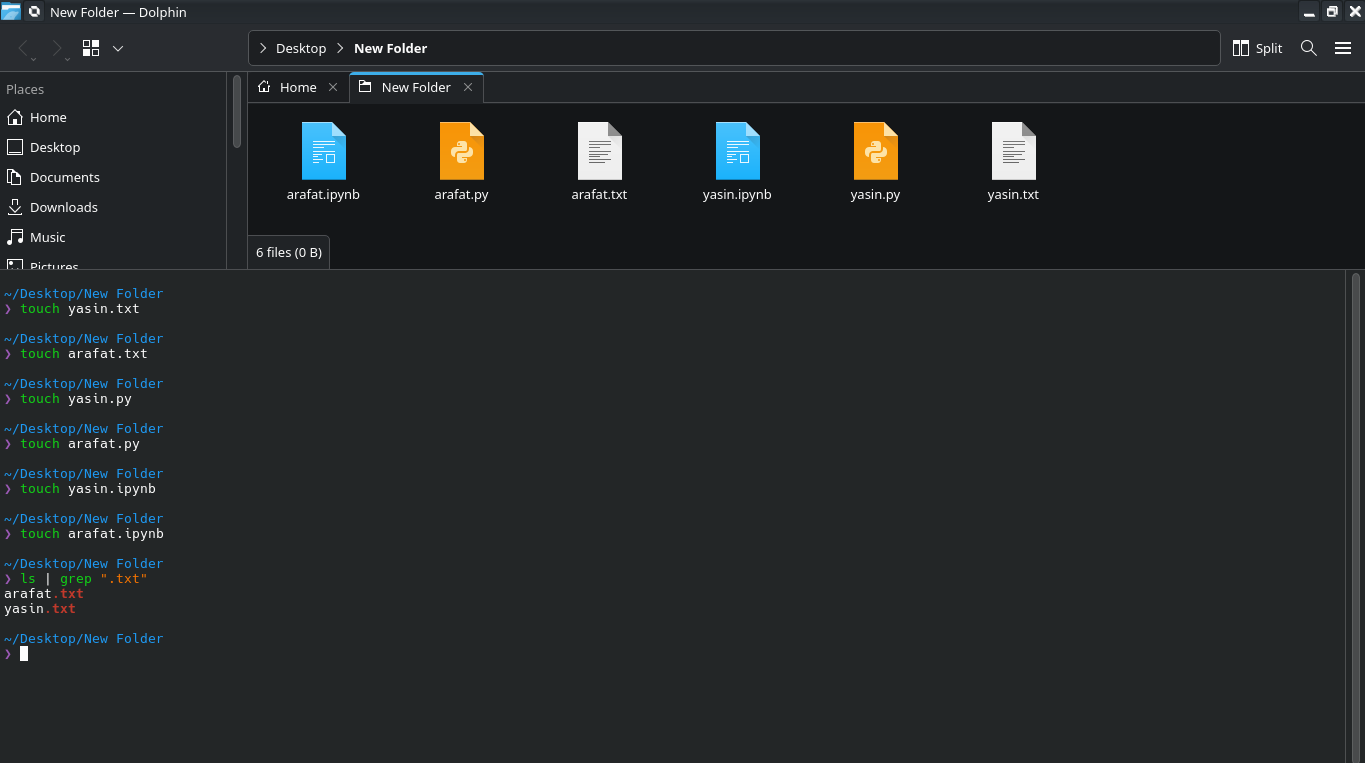

In [4]:
from IPython.display import Image
Image("../img/img02.png")



```bash
~/Desktop/New Folder   
❯ touch yasin.txt  

~/Desktop/New Folder   
❯ touch arafat.txt

~/Desktop/New Folder   
❯ touch yasin.py  
                                                         
~/Desktop/New Folder   
❯ touch arafat.py 
                                                        
~/Desktop/New Folder   
❯ touch yasin.ipynb
                                                         
~/Desktop/New Folder   
❯ touch arafat.ipynb
                                                    
~/Desktop/New Folder   
❯ ls | grep ".txt"       
arafat.txt
yasin.txt         

~/Desktop/New Folder   
❯ 

```

**Piping is a method where the output of one command is sent directly as the input to another command. In Linux, it is represented by the | symbol.**

<br>


<br>


# `#03: ls(Linux) vs dir(Windows) and grep(linux) vs Select-String(Windows)`

<br>



### 1. `ls` (Linux) vs. `dir` (Windows)
Both commands are used to list directory contents, but they handle data differently.

| Feature | `ls` (Linux/Bash) | `dir` (Windows/PowerShell) |
| :--- | :--- | :--- |
| **Primary Output** | Primarily text-based listing of filenames. | In PowerShell, it outputs **Objects** with properties. |
| **Common Flag** | `ls -l` (Shows permissions, owner, size, etc.). | `dir` (Shows Mode, LastWriteTime, Length by default). |
| **Hidden Files** | Use `ls -a` to see files starting with a `.`. | Use `dir -Force` to see hidden/system files. |
| **Color Coding** | Often color-coded by file type (blue for dirs). | Usually plain text, but PowerShell can style it. |



### 2. `grep` (Linux) vs. `Select-String` (Windows)
These are "search" tools used to find specific text patterns. 

| Feature | `grep` (Linux) | `Select-String` (Windows) |
| :--- | :--- | :--- |
| **Logic** | **Text Stream:** Filters raw lines of text. | **Object-Oriented:** Filters properties of objects. |
| **Syntax** | `cat file.txt | grep "pattern"` | `Get-Content file.txt | Select-String "pattern"` |
| **Case Sensitivity** | Case-sensitive by default (use `-i` to ignore). | Case-insensitive by default (use `-CaseSensitive`). |
| **Result Detail** | Returns the matching line of text. | Returns a `MatchInfo` object (Line number, Path, etc.). |



### **Key Takeaway for your Report:**
* **Linux commands (`ls`, `grep`)** are part of the "everything is a file/text" philosophy. You manipulate strings to get results.
* **Windows commands (`dir`, `Select-String`)** in PowerShell follow the "everything is an object" philosophy. This allows you to access specific properties (like just the "Size" or "CreationDate") much more easily than parsing text.

<br>

<br>

# `#04: PowerShell Scripting, Windows Registry Basics, Environmnet Variables`

<br>



### 1. PowerShell Scripting
PowerShell is a task automation and configuration management program from Microsoft consisting of command-line shell and the associated scripting language. Initially, it was a Windows componenet only, knows as Windows PowerShell, later it was made open source and cross-platfrom on August 2016 with the introductino of PowerShell Core. 

The current version is developed using .NET core framework and version number is 7.x.

* **Cmdlets**: These are built-in commands with a `Verb-Noun` structure (e.g., `Get-Service`, `Stop-Process`).
* **The Pipeline**: While Linux pipes text, PowerShell pipes entire **objects**, allowing you to filter data by specific properties (like file size or creation date) without complex text parsing.
* **Execution Policy**: For security, Windows often blocks script execution by default. You may need to use `Set-ExecutionPolicy RemoteSigned` to run your own scripts.



### 2. Windows Registry Basics
The Registry is a hierarchical database that stores low-level settings for the Windows OS and for applications that opt to use it.



* **Structure**: It is organized into "Hives." The most common ones you'll interact with are:
    * `HKEY_LOCAL_MACHINE` (HKLM): Settings for the entire computer (affects all users).
    * `HKEY_CURRENT_USER` (HKCU): Settings specific to the user currently logged in.
* **Keys and Values**: Keys act like folders, and Values act like files containing the actual data (Strings, Integers, etc.).
* **Lab Tip**: In PowerShell, you can navigate the registry just like a hard drive using `cd HKCU:\`.



### 3. Environment Variables
These are dynamic "values" that the OS and other software use to determine where files are located or how the system behaves.



* **Types**:
    * **System Variables**: Global settings that apply to all users (e.g., `%SystemRoot%`).
    * **User Variables**: Settings specific to one user (e.g., `%TEMP%`).
* **The PATH Variable**: Perhaps the most important variable. It tells the OS which folders to look in when you type a command. If a folder isn't in the **PATH**, the command won't run unless you type the full directory.
* **PowerShell Access**: You can view environment variables in PowerShell using the `Env:` drive:
    ```powershell
    Get-ChildItem Env:
    ```

---

### Comparison Summary for Task (iii)
Note that while Linux uses files in `/etc/` or hidden "dotfiles" (like `.bashrc`) for configuration, Windows relies heavily on the **Registry** and **Environment Variables**.

<br>


<br>
<br>

# `#05: fork() exec() wait()`

<br>
<br>

<br>

# 5.1: fork()

<br>

In [ ]:

import os 
import time 


""" 
i) ====== os.getpid() ======
ps -p 6073

or 
1) htop 
2) F4 -> search for -> python 
"""


def linux_process():
    print(f"parent process: {os.getpid()}")
    time.sleep(20)
linux_process()


parent process: 6073


<br>

---

### 1. Why lines after `fork()` run twice?
When `os.fork()` is called, the Operating System creates an exact **duplicate** of the current process. Now you have two independent processes (Parent and Child) running the exact same code starting from the very next line.
* `print(f"child process: {pid}")`: Both processes execute this, so you see it twice.
* `time.sleep(20)`: Both processes go to sleep for 20 seconds.

### 2. Why lines before `fork()` appeared twice? (The Buffer Mystery)
Technically, lines before `fork()` should only run once. However, Python uses **Output Buffering** to improve performance. Instead of sending text to the screen immediately, it stores it in a temporary memory "bucket" called a buffer.

* **The Trap:** When you printed `parent process: ...`, the text was sitting in the buffer but hadn't been "flushed" (sent) to the screen yet.
* **The Clone:** When `os.fork()` executed, the OS copied the **entire memory** of the parent—including that half-full buffer—into the child.
* **The Double Output:** Eventually, both the Parent and the Child finished their work and emptied their buffers. Since both buffers contained the old "parent process" text, it appeared twice on your screen.



### How to fix it?
Use `sys.stdout.flush()` right before `fork()` to empty the bucket, or run your script with the `-u` flag (unbuffered mode).

---

<br>

In [22]:

def linux_process():
    print(f"parent process: {os.getpid()}")
    
    # os.fork() will create a child process cloning the main process
    pid = os.fork()
    print(f"child process: {pid}")
    print("--------------------------")
    time.sleep(20)
linux_process()


parent process: 6073
child process: 0
--------------------------
parent process: 6073
child process: 12303
--------------------------


/tmp/ipykernel_6073/1096900274.py:5: DeprecationWarning: This process (pid=6073) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()


In [27]:
import sys 

def linux_process():
    print(f"parent process: {os.getpid()}")
    
    # remove the print buffer:
    sys.stdout.flush()
    
    # clone parent process(we have now two process)
    pid = os.fork()
    print(f'child process: {pid}')
    print()
    time.sleep(20)
linux_process()


parent process: 6073
child process: 0

child process: 14325



/tmp/ipykernel_6073/2625513307.py:10: DeprecationWarning: This process (pid=6073) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()


<br>

# 5.2: Difference between os.frok() vs threading.start()

<br>

In [4]:
import os 
import time 
import threading 

def linux_process():
    print(f"parent process: {os.getpid()}")
    time.sleep(20)
    

# threading is not create a new process 
# it's just create another thread inside one process
t1 = threading.Thread(target=linux_process,args=())
t2 = threading.Thread(target=linux_process,args=())

t1.start()
t2.start()

t1.join()
t2.join()


parent process: 2053
parent process: 2053


<br>

# 5.3 exec():

**The os.exec family of functions (like execl, execv, etc.) replaces the current process with a new one**

<br>

In [1]:

# import os 
# import time 

# def func1():
#     print("enter in func2")
#     os.execl("/bin/ls","ls","-l")
#     print("exit from func2")
    
# func1()
    
## ++++++++++++++++++++ see from os_exec.py file: ++++++++++++++++++++
##


<br>

# 5.4 wait():

---

### 1. Why do we need `wait()`?
When a child process finishes (dies), it doesn't disappear completely from the system. It leaves behind a small amount of information (like its exit status and PID) so the parent can check if it finished successfully.

* **Without `wait()`:** The child stays in the system as a **Zombie process** (`<defunct>`). It’s dead, but it’s still taking up a slot in the system's "Process Table."
* **With `wait()`:** The parent "collects" the child's exit information. Once the parent acknowledges the death, the child is fully removed from the system.


### 3. Real-World Analogy: The Restaurant
* **Process:** The Restaurant.
* **Parent:** The Manager.
* **Child:** The Waiter.
* **The Task:** Serving a customer.
* **The Wait:** The Waiter (Child) goes to the kitchen to get food. The Manager (Parent) doesn't just forget the Waiter exists. The Manager **waits** for the Waiter to return and report, "The customer is served" (Exit Status). Only after that report is the task officially cleared from the "To-Do" list.


**আচ্ছা, আমার যখন parent process থেকে child process বানায় তখন zero return করে  child বুঝায় আমি মাত্র তৈরি হয়ছি । কিন্তু যখন child process শেষ হয় তখন parent কে  জানানোর দরকার যাতে parent child এর জন্য যা pid and status reseve করেছিলো তা system থেকে delete করে দিবে । কিতু যদি parent না জানে তখন ghost prcess or zoombe process তৈরি হয় । একটি চাইল্ড প্রসেস যখন তার কাজ শেষ করে (যেমন os._exit(0) কল করে), তখন অপারেটিং সিস্টেম তার মেমোরি এবং ফাইলগুলো খালি করে দেয়। কিন্তু সে প্রসেস টেবিল থেকে তার ID (PID) এবং Exit Status মুছে ফেলে না। এই অবস্থাকেই আমরা বলি Zombie Process (জম্বি)। সে মৃত, কিন্তু তার আত্মা (PID) এখনও সিস্টেমের টেবিলে রয়ে গেছে। অনেক বেশি জম্বি হয়ে গেলে সিস্টেম নতুন কোনো প্রসেস তৈরি করতে পারবে না।**

---

<br>

In [ ]:

import os 
import time 
import warnings

warnings.filterwarnings('ignore')

pid = os.fork()

if pid==0:
    print("Child process created:)")
    print("I will work for 3 seconds.")
    time.sleep(3)
    os._exit(0)
else:
    print("=========X==============")
    print("I am parent process. Waiting for the child process to finish")
    
    # this passes the parent process for child finish.....
    child_pid, status = os.wait()
    
    print(f"Parent: child pid:{child_pid} status:{status} finish. Now i continue...")
    



Child process created:)
I will work for 3 seconds.


=========X==============
I am parent process. Waiting for the child process to finish
Parent: child pid:14593 status:0 finish. Now i continue...


In [ ]:

# observe a zoombie process:
"""
#Run this for capturing the zoombie process
# z-> means zoombie process
# ps aux -> fetch all the current process running on linux
ps aux | grep Z
"""


import os 
import sys
import time 
def zoombe_process():
    
    # print the process id and remove the flash
    print(f"parent process with PID: {os.getpid()}")
    sys.stdout.flush()
    
    
    pid = os.fork()
    
    if pid==0:
        print("child process created.")
        print(f"child process with PID: {os.getpid()} exiting.")
        os._exit(0)
    else:
        print(f"Parent process with PID: {os.getpid()}")
        print("Parent will alive for 60 seconds.")
        time.sleep(60)

zoombe_process()

child process created.
child process with PID: 16342 exiting.


Parent process with PID6801
Parent will alive for 60 seconds.


<br>
<br>

# `#06: Signal module in python:`

<br>
<br>


In Python, signal handling is essentially the bridge between the **Operating System** (which manages events like hardware interrupts) and your **Script**. When the OS wants to tell your program to stop, restart, or clean up, it sends a signal.

Here are the basics you need to master:

---

### 1. The `signal` Module
To handle signals in Python, you use the built-in `signal` module. It allows you to define a **handler function** that executes whenever a specific signal is received.

### 2. Common Linux Signals in Python
While there are dozens of signals, these are the ones you will use 99% of the time:

| Signal | Python Constant | Trigger | Typical Use Case |
| :--- | :--- | :--- | :--- |
| **Interrupt** | `signal.SIGINT` | `Ctrl+C` | Graceful shutdown or stopping a loop. |
| **Terminate** | `signal.SIGTERM` | `kill [pid]` | Standard "stop" request from the system. |
| **Alarm** | `signal.SIGALRM` | Timers | Setting a timeout for a specific operation. |
| **Hangup** | `signal.SIGHUP` | Terminal closed | Reloading configuration files without restarting. |



In [ ]:

# import signal

# def signal_handeler(sig,frame):
#     print(f"received signal {sig}. cleaning up . . .")
    
# signal.signal(signalnum=signal.SIGINT,handler=signal_handeler)

#
# See signal_code.py
#